In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import sklearn
print(sklearn.__version__)

1.6.1


### 1. LOAD DATA & AUTO-FILL ASPECT

In [ ]:
print("Loading dataset hasil koreksi...")
df = pd.read_csv('data/absa_dataset_sampled.csv')

aspect_keywords = {
    'Anggaran': ['anggaran', 'dana', 'uang', 'pajak', 'korupsi', 'triliun', 'biaya'],
    'Menu & Gizi': ['menu', 'susu', 'makan', 'gizi', 'nasi', 'lauk', 'sayur', 'telur'],
    'Distribusi': ['distribusi', 'sekolah', 'daerah', 'papua', 'desa', 'merata', 'tepat sasaran'],
    'Pemerintah': ['pemerintah', 'prabowo', 'gibran', 'menteri', 'kebijakan', 'program']
}

def detect_aspect(text):
    text_lower = str(text).lower()
    for aspect, keywords in aspect_keywords.items():
        if any(keyword in text_lower for keyword in keywords):
            return aspect
    return 'Umum'

df['Aspect'] = df['Clean_Comment'].apply(detect_aspect)

Loading dataset hasil koreksi...


### 2. FITUR TF-IDF, CEK DISTRIBUSI, & SPLIT DATA

In [ ]:
df['Clean_Comment'] = df['Clean_Comment'].fillna("")
df['Aspect'] = df['Aspect'].fillna("Umum")
df['Feature_Text'] = df['Aspect'] + " " + df['Clean_Comment']

vectorizer = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['Feature_Text'])
y = df['Sentiment']

joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')
print("✅ Vectorizer disimpan ke 'models/tfidf_vectorizer.joblib'")

print("\n[INFO DATASET SEBELUM SPLIT]")
print(f"Total data siap training: {len(df)} baris")
print("Distribusi Kelas Sentimen Aktual:")
print(y.value_counts())
print("-" * 50)

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

✅ Vectorizer disimpan ke 'models/tfidf_vectorizer.joblib'

[INFO DATASET SEBELUM SPLIT]
Total data siap training: 450 baris
Distribusi Kelas Sentimen Aktual:
Sentiment
negative    150
neutral     150
positive    150
Name: count, dtype: int64
--------------------------------------------------


### 3. TRAINING, EVALUASI, & VISUALISASI PER MODEL

In [ ]:
models = {
    "SVM": SVC(kernel='linear', C=1.0, random_state=42, probability=True),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive_Bayes": MultinomialNB(),
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42)
}


🚀 MODEL: SVM
✅ Model SVM berhasil dilatih dan disimpan ke 'svm_model.joblib'

[1. METRIK EVALUASI]
Accuracy : 0.5889

Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.73      0.69        30
     neutral       0.54      0.43      0.48        30
    positive       0.56      0.60      0.58        30

    accuracy                           0.59        90
   macro avg       0.58      0.59      0.58        90
weighted avg       0.58      0.59      0.58        90


[2. CONFUSION MATRIX]


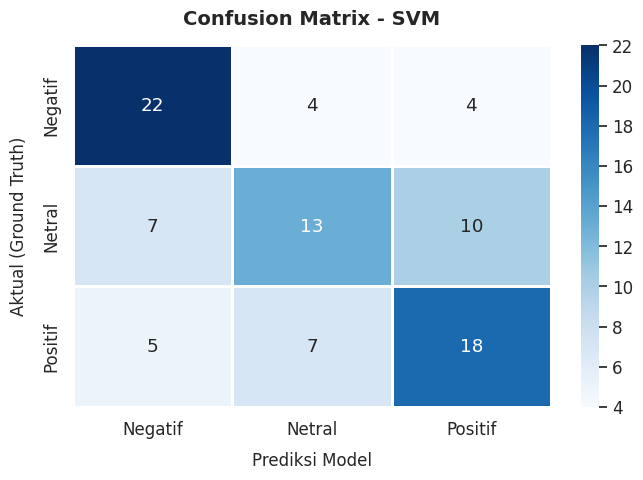


[3. ERROR ANALYSIS - 5 Contoh Kesalahan Prediksi]
- Aspek       : Umum
  Teks Asli   : Utk ibu hamil dan balita bekerja sama lah dgn bgn posyandu yg sdh mberi mknan tambahan pd balita dan...
  Teks Bersih : utk ibu hamil balita kerja sama lah dgn bgn posyandu sdh mberi mknan tambah pd balita ibu hml
  Aktual      : NEUTRAL | Prediksi : POSITIVE
--------------------------------------------------
- Aspek       : Anggaran
  Teks Asli   : MBG knp tdk memanfaatkan kantin2 sekolah saja, agar tdk terbuang anggaran sewa dapur...
  Teks Bersih : makan gizi gratis knp tdk manfaat kantin sekolah agar tdk buang anggar sewa dapur
  Aktual      : NEUTRAL | Prediksi : NEGATIVE
--------------------------------------------------
- Aspek       : Menu & Gizi
  Teks Asli   : sampai sekarang menu mbg, pisang / jeruk 1 biji + susu kotak atau ada nasi, tapi tahu tipis, tempe t...
  Teks Bersih : sekarang menu makan gizi gratis pisang jeruk biji susu kotak ada nasi tahu tipis tempe tipis ayam tulang nya gizi

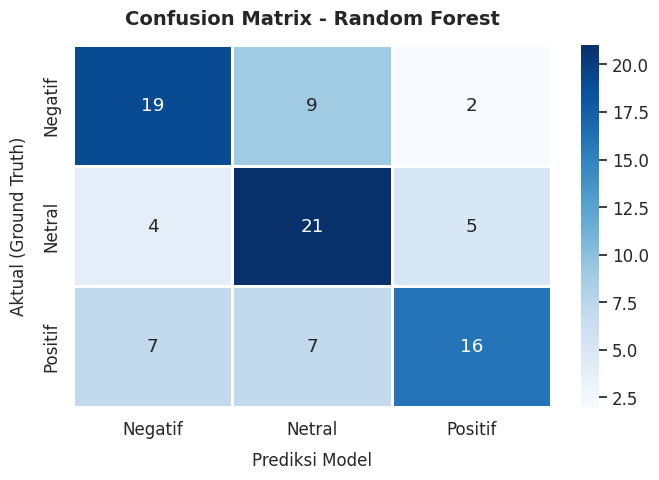


[3. ERROR ANALYSIS - 5 Contoh Kesalahan Prediksi]
- Aspek       : Umum
  Teks Asli   : Utk ibu hamil dan balita bekerja sama lah dgn bgn posyandu yg sdh mberi mknan tambahan pd balita dan...
  Teks Bersih : utk ibu hamil balita kerja sama lah dgn bgn posyandu sdh mberi mknan tambah pd balita ibu hml
  Aktual      : NEUTRAL | Prediksi : POSITIVE
--------------------------------------------------
- Aspek       : Menu & Gizi
  Teks Asli   : Alhamdulillah mantap bang  semoga orang2 yg di MBG amanah dalam menjalankn tugasnya.<br>Kasiahan ind...
  Teks Bersih : alhamdulillah mantap bang moga orang di makan gizi gratis amanah menjalankn tugas kasiahan indonesia rakyat nya jt
  Aktual      : POSITIVE | Prediksi : NEUTRAL
--------------------------------------------------
- Aspek       : Anggaran
  Teks Asli   : MBG knp tdk memanfaatkan kantin2 sekolah saja, agar tdk terbuang anggaran sewa dapur...
  Teks Bersih : makan gizi gratis knp tdk manfaat kantin sekolah agar tdk buang anggar sewa dapu

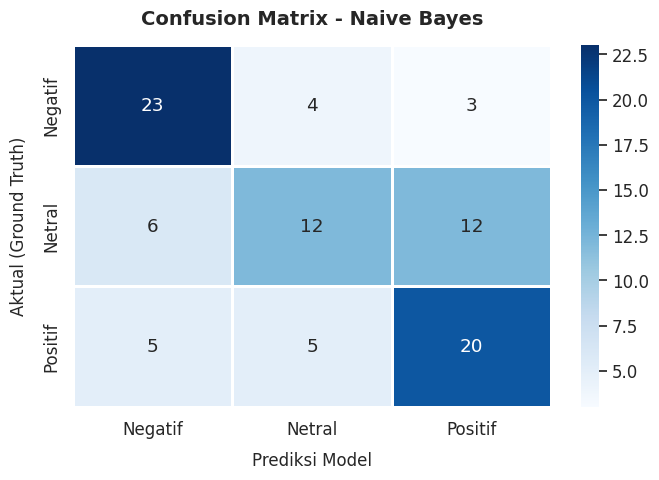


[3. ERROR ANALYSIS - 5 Contoh Kesalahan Prediksi]
- Aspek       : Umum
  Teks Asli   : Utk ibu hamil dan balita bekerja sama lah dgn bgn posyandu yg sdh mberi mknan tambahan pd balita dan...
  Teks Bersih : utk ibu hamil balita kerja sama lah dgn bgn posyandu sdh mberi mknan tambah pd balita ibu hml
  Aktual      : NEUTRAL | Prediksi : POSITIVE
--------------------------------------------------
- Aspek       : Anggaran
  Teks Asli   : MBG knp tdk memanfaatkan kantin2 sekolah saja, agar tdk terbuang anggaran sewa dapur...
  Teks Bersih : makan gizi gratis knp tdk manfaat kantin sekolah agar tdk buang anggar sewa dapur
  Aktual      : NEUTRAL | Prediksi : NEGATIVE
--------------------------------------------------
- Aspek       : Menu & Gizi
  Teks Asli   : sampai sekarang menu mbg, pisang / jeruk 1 biji + susu kotak atau ada nasi, tapi tahu tipis, tempe t...
  Teks Bersih : sekarang menu makan gizi gratis pisang jeruk biji susu kotak ada nasi tahu tipis tempe tipis ayam tulang nya gizi

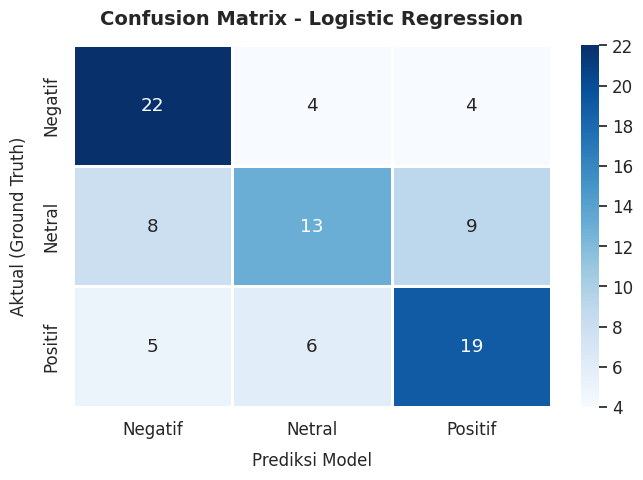


[3. ERROR ANALYSIS - 5 Contoh Kesalahan Prediksi]
- Aspek       : Umum
  Teks Asli   : Utk ibu hamil dan balita bekerja sama lah dgn bgn posyandu yg sdh mberi mknan tambahan pd balita dan...
  Teks Bersih : utk ibu hamil balita kerja sama lah dgn bgn posyandu sdh mberi mknan tambah pd balita ibu hml
  Aktual      : NEUTRAL | Prediksi : NEGATIVE
--------------------------------------------------
- Aspek       : Anggaran
  Teks Asli   : MBG knp tdk memanfaatkan kantin2 sekolah saja, agar tdk terbuang anggaran sewa dapur...
  Teks Bersih : makan gizi gratis knp tdk manfaat kantin sekolah agar tdk buang anggar sewa dapur
  Aktual      : NEUTRAL | Prediksi : NEGATIVE
--------------------------------------------------
- Aspek       : Menu & Gizi
  Teks Asli   : sampai sekarang menu mbg, pisang / jeruk 1 biji + susu kotak atau ada nasi, tapi tahu tipis, tempe t...
  Teks Bersih : sekarang menu makan gizi gratis pisang jeruk biji susu kotak ada nasi tahu tipis tempe tipis ayam tulang nya gizi

In [ ]:
test_df_base = df.iloc[indices_test].copy()

# Mengatur style visual Seaborn agar elegan
sns.set_theme(style="whitegrid", font_scale=1.1)

for name, model in models.items():
    print("\n" + "="*70)
    print(f"🚀 MODEL: {name.replace('_', ' ').upper()}")
    print("="*70)
    
    # Training Model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Export model ke .joblib
    filename = f"{name.lower()}_model.joblib"
    joblib.dump(model, filename)
    
    print(f"✅ Model {name} berhasil dilatih dan disimpan ke '{filename}'")
# --- A. METRIK EVALUASI ---
    print(f"\n[1. METRIK EVALUASI]")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
# --- B. VISUALISASI CONFUSION MATRIX ---
    print("\n[2. CONFUSION MATRIX]")
    cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
    
    # Membuat figure matplotlib
    plt.figure(figsize=(7, 5))
    
    # Menggambar Heatmap menggunakan Seaborn
    # cmap='Blues' memberikan gradasi warna biru yang profesional
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='white',
                     xticklabels=['Negatif', 'Netral', 'Positif'],
                     yticklabels=['Negatif', 'Netral', 'Positif'])
    
    plt.title(f'Confusion Matrix - {name.replace("_", " ")}', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Prediksi Model', fontsize=12, labelpad=10)
    plt.ylabel('Aktual (Ground Truth)', fontsize=12, labelpad=10)
    plt.tight_layout()
    
    # Menampilkan confusion matrix
    plt.show()
    
# --- C. ERROR ANALYSIS ---
    print("\n[3. ERROR ANALYSIS - 5 Contoh Kesalahan Prediksi]")
    test_df = test_df_base.copy()
    test_df['Predicted_Sentiment'] = y_pred
    
    errors = test_df[test_df['Sentiment'] != test_df['Predicted_Sentiment']].head(5)
    
    if len(errors) == 0:
        print("Hebat! Model ini memprediksi seluruh 5 data teratas dengan benar.")
    else:
        for i, row in errors.iterrows():
            print(f"- Aspek       : {row['Aspect']}")
            print(f"  Teks Asli   : {row['Comment'][:100]}...") 
            print(f"  Teks Bersih : {row['Clean_Comment']}")
            print(f"  Aktual      : {row['Sentiment'].upper()} | Prediksi : {row['Predicted_Sentiment'].upper()}")
            print("-" * 50)

print("\n🎉 EKSPERIMEN MULTI-MODEL & VISUALISASI SELESAI!")